# Linear Regression in Python: A Beginner's Guide

**Learning Objectives:**
- Understand how to work with data in Python using pandas and numpy
- Visualize relationships between variables
- Understand correlation and its interpretation
- Build a linear regression model
- Evaluate model performance using R², MSE, MAE, and MAPE

---

## Part 1: Setting Up Python Environment

Think of these libraries as specialized toolkits:
- **numpy**: Mathematical operations (like a calculator on steroids)
- **pandas**: Data handling (like Excel, but programmable)
- **matplotlib**: Creating plots and visualizations
- **sklearn**: Machine learning algorithms (includes linear regression)

In [ ]:
# Importing necessary libraries
import numpy as np                    # For numerical operations
import pandas as pd                   # For data manipulation
import matplotlib.pyplot as plt       # For plotting
from sklearn.linear_model import LinearRegression  # For regression modeling
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# # This makes plots appear in the notebook
# %matplotlib inline

# # Making plots look better
# plt.style.use('seaborn-v0_8-darkgrid')
# plt.rcParams['figure.figsize'] = (10, 6)

# print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [ ]:
df = pd.read_csv(

## Part 2: Loading and Understanding Your Data

**The Dataset**: Years of experience vs. Salary

**Biological Analogy**: Just like we might study how plant height relates to sunlight exposure, here we're examining how salary relates to work experience.

In [2]:
# Creating the dataset (in real scenarios, you'd load from a CSV file)
data = {
    'YearsExperience': [1.1, 1.3, 1.5, 2, 2.2, 2.9, 3, 3.2, 3.2, 3.7, 3.9, 4, 4, 4.1, 4.5, 4.9, 
                        5.1, 5.3, 5.9, 6, 6.8, 7.1, 7.9, 8.2, 8.7, 9, 9.5, 9.6, 10.3, 10.5],
    'Salary': [39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445, 64445, 57189, 63218, 55794, 
               56957, 57081, 61111, 67938, 66029, 83088, 81363, 93940, 91738, 98273, 101302, 113812, 
               109431, 105582, 116969, 112635, 122391, 121872]
}

# Creating a DataFrame (think of it as an Excel spreadsheet in Python)
df = pd.DataFrame(data)

print("Dataset loaded successfully!")
print(f"\nWe have {len(df)} employees in our dataset\n")

Dataset loaded successfully!

We have 30 employees in our dataset



In [3]:
# Let's look at the first few rows (like scrolling to the top in Excel)
print("First 5 rows of data:")
df.head()

First 5 rows of data:


,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [4]:
# Basic statistics about our data
print("Summary Statistics:\n")
df.describe()

Summary Statistics:



,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


**Understanding the output:**
- **count**: Number of data points
- **mean**: Average value (like average height in a population)
- **std**: Standard deviation (how spread out the values are)
- **min/max**: Smallest and largest values
- **25%, 50%, 75%**: Quartiles (dividing data into quarters)

## Part 3: Visualizing the Relationship

**Why visualize?** In biology, we use microscopes to see cells. In data science, we use plots to "see" patterns!

Let's create a scatter plot to see if there's a relationship between experience and salary.

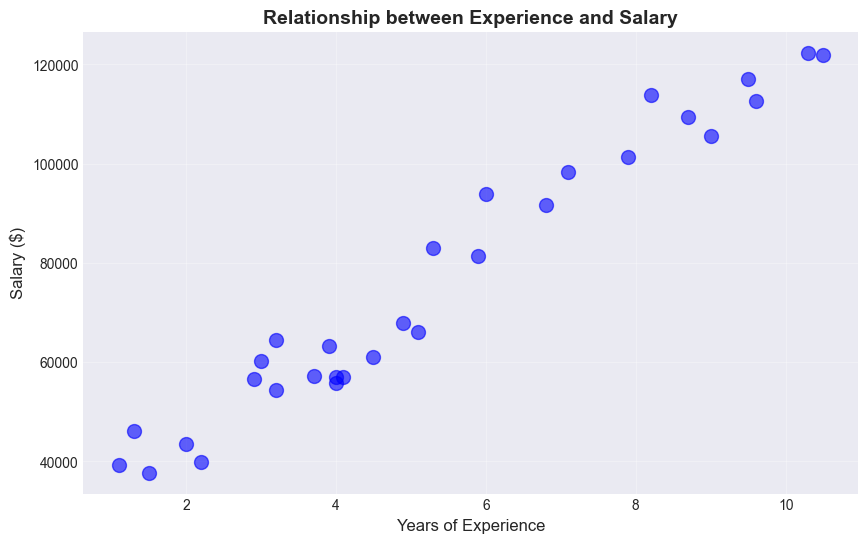


👀 What do you observe?
   • Do the points seem to follow a pattern?
   • As experience increases, what happens to salary?


In [5]:
# Creating a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['YearsExperience'], df['Salary'], color='blue', alpha=0.6, s=100)
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary ($)', fontsize=12)
plt.title('Relationship between Experience and Salary', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

print("\n👀 What do you observe?")
print("   • Do the points seem to follow a pattern?")
print("   • As experience increases, what happens to salary?")

## Part 4: Understanding Correlation

**What is Correlation?**

Correlation measures how two variables move together. Think of it like this:
- In biology: taller plants often have more leaves (positive correlation)
- In medicine: higher antibiotic dose might reduce bacterial count (negative correlation)

**Correlation coefficient (r)** ranges from -1 to +1:
- **r = +1**: Perfect positive relationship (as X increases, Y increases)
- **r = 0**: No linear relationship
- **r = -1**: Perfect negative relationship (as X increases, Y decreases)

**Rules of thumb:**
- |r| > 0.7: Strong correlation
- 0.3 < |r| < 0.7: Moderate correlation
- |r| < 0.3: Weak correlation

In [6]:
# Calculating correlation
correlation = df['YearsExperience'].corr(df['Salary'])

print(f"Correlation coefficient (r): {correlation:.4f}")
print(f"\n📊 Interpretation:")
if correlation > 0.7:
    print(f"   Strong positive correlation! As experience increases, salary tends to increase.")
elif correlation > 0.3:
    print(f"   Moderate positive correlation.")
else:
    print(f"   Weak correlation.")

# Full correlation matrix
print("\nCorrelation Matrix:")
print(df.corr())

Correlation coefficient (r): 0.9782

📊 Interpretation:
   Strong positive correlation! As experience increases, salary tends to increase.

Correlation Matrix:
                 YearsExperience    Salary
YearsExperience         1.000000  0.978242
Salary                  0.978242  1.000000


⚠️ **Important Note**: Correlation ≠ Causation!

Just because two things correlate doesn't mean one causes the other. Example: Ice cream sales and drowning deaths are correlated (both increase in summer), but ice cream doesn't cause drowning!

## Part 5: Building a Linear Regression Model

**What is Linear Regression?**

Remember the equation from Excel: **Salary = m × Experience + c**

Where:
- **m** = slope (how much salary increases per year of experience)
- **c** = intercept (theoretical salary with 0 years experience)

**In machine learning notation:**
- **y = mx + c** is written as **ŷ = β₁x + β₀**
- **ŷ** (y-hat) = predicted value
- **β₁** = slope coefficient
- **β₀** = intercept

### Method 1: Using sklearn (the easy way!)

In [7]:
# Preparing the data
# X must be 2D array (hence reshape), y can be 1D
X = df['YearsExperience'].values.reshape(-1, 1)  # Independent variable (input)
y = df['Salary'].values                           # Dependent variable (output)

print(f"Shape of X: {X.shape}  (30 samples, 1 feature)")
print(f"Shape of y: {y.shape}  (30 samples)")

Shape of X: (30, 1)  (30 samples, 1 feature)
Shape of y: (30,)  (30 samples)


In [8]:
# Creating and training the model
model = LinearRegression()
model.fit(X, y)

# Getting the coefficients (m and c from Excel!)
slope = model.coef_[0]
intercept = model.intercept_

print("="*50)
print("MODEL PARAMETERS")
print("="*50)
print(f"Slope (m or β₁):     ${slope:,.2f}")
print(f"Intercept (c or β₀): ${intercept:,.2f}")
print("\n📐 The equation of our line:")
print(f"   Salary = {slope:.2f} × Experience + {intercept:.2f}")
print("\n💡 Interpretation:")
print(f"   • For each additional year of experience, salary increases by ${slope:,.2f}")
print(f"   • A person with 0 years experience would theoretically earn ${intercept:,.2f}")

MODEL PARAMETERS
Slope (m or β₁):     $9,449.96
Intercept (c or β₀): $25,792.20

📐 The equation of our line:
   Salary = 9449.96 × Experience + 25792.20

💡 Interpretation:
   • For each additional year of experience, salary increases by $9,449.96
   • A person with 0 years experience would theoretically earn $25,792.20


### Visualizing the Regression Line

Let's plot our best-fit line on top of the actual data points!

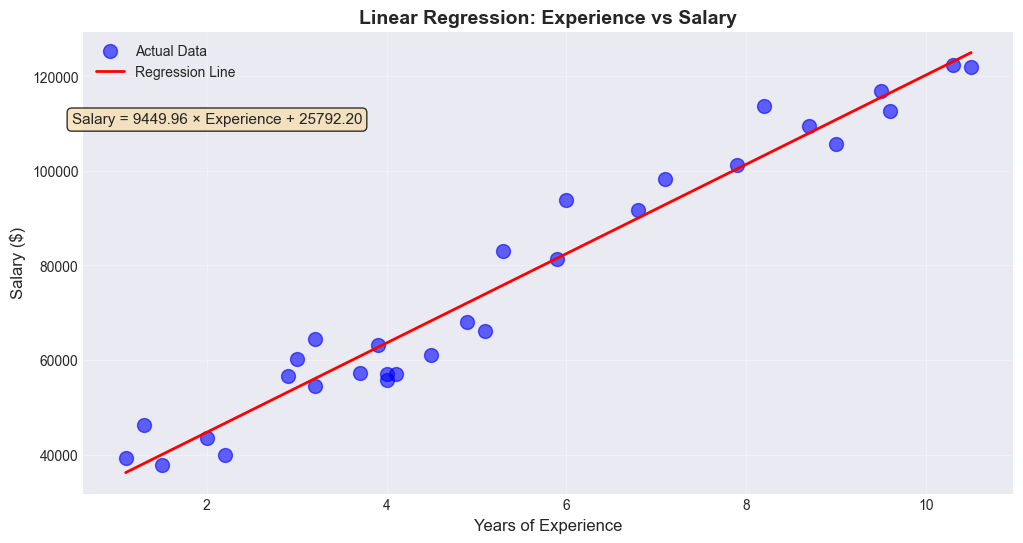

In [9]:
# Making predictions
y_pred = model.predict(X)

# Plotting
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='blue', alpha=0.6, s=100, label='Actual Data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary ($)', fontsize=12)
plt.title('Linear Regression: Experience vs Salary', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Adding the equation to the plot
equation_text = f'Salary = {slope:.2f} × Experience + {intercept:.2f}'
plt.text(0.5, 110000, equation_text, fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.show()

### Method 2: Understanding the Math (From Scratch)

Let's implement the OLS formulas you learned in Excel!

**Formulas:**

$$m = \frac{n(\sum xy) - (\sum x)(\sum y)}{n(\sum x^2) - (\sum x)^2}$$

$$c = \bar{y} - m\bar{x}$$

Where $\bar{x}$ and $\bar{y}$ are means of x and y.

In [10]:
# Calculating slope and intercept from scratch
x = df['YearsExperience'].values
y = df['Salary'].values

n = len(x)
x_mean = np.mean(x)
y_mean = np.mean(y)

# Calculating slope (m)
numerator = n * np.sum(x * y) - np.sum(x) * np.sum(y)
denominator = n * np.sum(x**2) - (np.sum(x))**2
m_manual = numerator / denominator

# Calculating intercept (c)
c_manual = y_mean - m_manual * x_mean

print("MANUAL CALCULATION (From Scratch)")
print("="*50)
print(f"Slope (m):     ${m_manual:,.2f}")
print(f"Intercept (c): ${c_manual:,.2f}")
print("\n✓ Matches sklearn results! Both methods give the same answer.")

MANUAL CALCULATION (From Scratch)
Slope (m):     $9,449.96
Intercept (c): $25,792.20

✓ Matches sklearn results! Both methods give the same answer.


In [11]:
import statsmodels.api as sm
# Add constant term for intercept
X_sm = sm.add_constant(X)
# Fit OLS model
model = sm.OLS(y, X_sm).fit()

In [12]:
print("\n===== STATSMODELS OLS SUMMARY =====")
print(model.summary())


===== STATSMODELS OLS SUMMARY =====
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     622.5
Date:                Tue, 03 Feb 2026   Prob (F-statistic):           1.14e-20
Time:                        21:54:41   Log-Likelihood:                -301.44
No. Observations:                  30   AIC:                             606.9
Df Residuals:                      28   BIC:                             609.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.5

## Part 6: Model Evaluation Metrics

Now that we have a model, we need to ask: **"How good is it?"**

We'll use several metrics to evaluate our model's performance.

### 6.1 R² (R-Squared) - Coefficient of Determination

**What is R²?**
- Tells us what percentage of variation in Y is explained by X
- Ranges from 0 to 1 (or 0% to 100%)
- **R² = 0.85** means 85% of salary variation is explained by experience

**Biological Analogy**: If we're studying plant growth:
- R² = 0.9 → 90% of height variation is explained by sunlight (very good!)
- R² = 0.3 → Only 30% explained by sunlight (other factors matter more)

**Formula:**
$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

Where:
- $y_i$ = actual value
- $\hat{y}_i$ = predicted value
- $\bar{y}$ = mean of actual values

In [13]:
# Calculating R²
r2 = r2_score(y, y_pred)

# Manual calculation for understanding
ss_res = np.sum((y - y_pred)**2)  # Residual sum of squares
ss_tot = np.sum((y - np.mean(y))**2)  # Total sum of squares
r2_manual = 1 - (ss_res / ss_tot)

print("R² (R-SQUARED)")
print("="*50)
print(f"R² score: {r2:.4f} or {r2*100:.2f}%")
print(f"\n📊 Interpretation:")
print(f"   {r2*100:.1f}% of the variation in Salary can be explained by Years of Experience")
print(f"   Remaining {(1-r2)*100:.1f}% is due to other factors (education, skills, company, etc.)")

# Relationship between r and R²
print(f"\n🔗 Note: R² = r² = {correlation:.4f}² = {correlation**2:.4f}")
print("   (For simple linear regression, R² equals the squared correlation coefficient)")

R² (R-SQUARED)
R² score: 0.9570 or 95.70%

📊 Interpretation:
   95.7% of the variation in Salary can be explained by Years of Experience
   Remaining 4.3% is due to other factors (education, skills, company, etc.)

🔗 Note: R² = r² = 0.9782² = 0.9570
   (For simple linear regression, R² equals the squared correlation coefficient)


### 6.2 MSE (Mean Squared Error)

**What is MSE?**
- Average of squared differences between actual and predicted values
- Penalizes large errors more heavily (because we square them)
- **Lower is better** (0 = perfect predictions)
- Units: (dollars)² in our case

**Formula:**
$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**Why square the errors?**
- Makes all errors positive (otherwise +5 and -5 would cancel out)
- Emphasizes larger errors (an error of 10 contributes 100 to MSE)

In [14]:
# Calculating MSE
mse = mean_squared_error(y, y_pred)

# Manual calculation
errors = y - y_pred
mse_manual = np.mean(errors**2)

# RMSE (Root Mean Squared Error) - more interpretable
rmse = np.sqrt(mse)

print("MSE (MEAN SQUARED ERROR)")
print("="*50)
print(f"MSE:  ${mse:,.2f}² (squared dollars)")
print(f"RMSE: ${rmse:,.2f} (back to dollar units)")
print(f"\n💡 Interpretation:")
print(f"   On average, our predictions are off by about ${rmse:,.0f}")
print(f"   This is approximately {(rmse/np.mean(y))*100:.1f}% of the average salary")

MSE (MEAN SQUARED ERROR)
MSE:  $31,270,951.72² (squared dollars)
RMSE: $5,592.04 (back to dollar units)

💡 Interpretation:
   On average, our predictions are off by about $5,592
   This is approximately 7.4% of the average salary


### 6.3 MAE (Mean Absolute Error)

**What is MAE?**
- Average of absolute differences between actual and predicted values
- More intuitive than MSE (no squaring)
- **Lower is better**
- Same units as Y (dollars in our case)

**Formula:**
$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

**MAE vs MSE:**
- MAE treats all errors equally
- MSE penalizes large errors more
- If MAE << MSE, you might have some large outliers

In [15]:
# Calculating MAE
mae = mean_absolute_error(y, y_pred)

# Manual calculation
mae_manual = np.mean(np.abs(errors))

print("MAE (MEAN ABSOLUTE ERROR)")
print("="*50)
print(f"MAE: ${mae:,.2f}")
print(f"\n💡 Interpretation:")
print(f"   On average, our predictions are off by ${mae:,.0f}")
print(f"   This is approximately {(mae/np.mean(y))*100:.1f}% of the average salary")

print(f"\n📊 Comparing MAE and RMSE:")
print(f"   MAE:  ${mae:,.0f}")
print(f"   RMSE: ${rmse:,.0f}")
if rmse > mae * 1.2:
    print(f"   ⚠️  RMSE is notably higher than MAE, suggesting some larger errors/outliers")
else:
    print(f"   ✓  RMSE and MAE are similar, suggesting consistent error distribution")

MAE (MEAN ABSOLUTE ERROR)
MAE: $4,644.20

💡 Interpretation:
   On average, our predictions are off by $4,644
   This is approximately 6.1% of the average salary

📊 Comparing MAE and RMSE:
   MAE:  $4,644
   RMSE: $5,592
   ⚠️  RMSE is notably higher than MAE, suggesting some larger errors/outliers


### 6.4 MAPE (Mean Absolute Percentage Error)

**What is MAPE?**
- Average of percentage errors
- Expressed as a percentage (easy to communicate!)
- Scale-independent (useful for comparing models across different datasets)
- **Lower is better**

**Formula:**
$$MAPE = \frac{100\%}{n}\sum_{i=1}^{n}\left|\frac{y_i - \hat{y}_i}{y_i}\right|$$

**Rules of thumb:**
- MAPE < 10%: Excellent
- MAPE 10-20%: Good
- MAPE 20-50%: Reasonable
- MAPE > 50%: Poor

⚠️ **Warning**: MAPE can't be used when actual values are zero!

In [16]:
# Calculating MAPE
mape = np.mean(np.abs((y - y_pred) / y)) * 100

print("MAPE (MEAN ABSOLUTE PERCENTAGE ERROR)")
print("="*50)
print(f"MAPE: {mape:.2f}%")
print(f"\n💡 Interpretation:")
print(f"   On average, our predictions are off by {mape:.1f}%")
if mape < 10:
    print(f"   ⭐ Excellent model performance!")
elif mape < 20:
    print(f"   ✓ Good model performance")
elif mape < 50:
    print(f"   ⚠️  Reasonable, but could be improved")
else:
    print(f"   ❌ Poor model performance")

MAPE (MEAN ABSOLUTE PERCENTAGE ERROR)
MAPE: 7.05%

💡 Interpretation:
   On average, our predictions are off by 7.0%
   ⭐ Excellent model performance!


### Summary of All Metrics

In [17]:
# Creating a summary table
metrics_summary = pd.DataFrame({
    'Metric': ['R² Score', 'RMSE', 'MAE', 'MAPE'],
    'Value': [f"{r2:.4f}", f"${rmse:,.2f}", f"${mae:,.2f}", f"{mape:.2f}%"],
    'Interpretation': [
        f"{r2*100:.1f}% of variance explained",
        f"Avg prediction error: ${rmse:,.0f}",
        f"Avg absolute error: ${mae:,.0f}",
        f"Avg percentage error: {mape:.1f}%"
    ]
})

print("\n" + "="*80)
print("MODEL EVALUATION SUMMARY")
print("="*80)
print(metrics_summary.to_string(index=False))
print("="*80)


MODEL EVALUATION SUMMARY
  Metric     Value               Interpretation
R² Score    0.9570  95.7% of variance explained
    RMSE $5,592.04 Avg prediction error: $5,592
     MAE $4,644.20   Avg absolute error: $4,644
    MAPE     7.05%   Avg percentage error: 7.0%


## Part 7: Visualizing Residuals (Errors)

**What are residuals?**
- Residual = Actual value - Predicted value
- They show us where our model made mistakes

**Good residual plot:**
- Points randomly scattered around zero
- No clear pattern
- Roughly equal spread

**Bad residual plot:**
- Clear pattern (curved, funnel-shaped)
- Suggests linear regression might not be the best fit

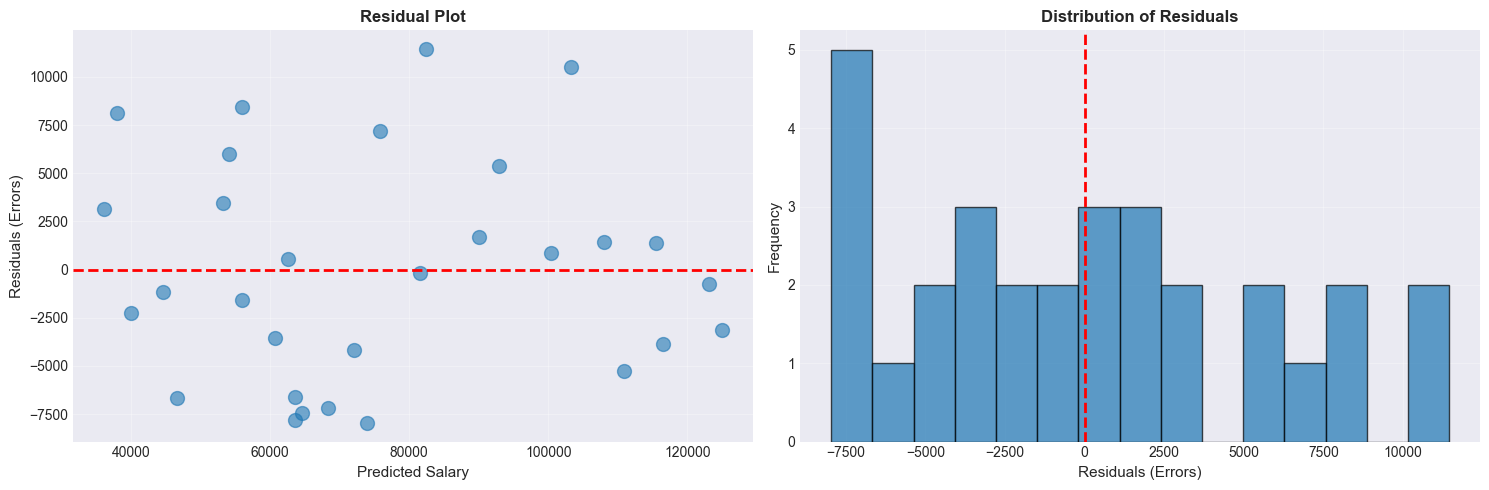

✓ Residuals look randomly scattered around zero - good sign!
✓ No clear pattern - linear regression is appropriate


In [18]:
# Calculating residuals
residuals = y - y_pred

# Creating residual plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Residuals vs Predicted Values
axes[0].scatter(y_pred, residuals, alpha=0.6, s=100)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Salary', fontsize=11)
axes[0].set_ylabel('Residuals (Errors)', fontsize=11)
axes[0].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Distribution of Residuals
axes[1].hist(residuals, bins=15, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals (Errors)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Residuals look randomly scattered around zero - good sign!")
print("✓ No clear pattern - linear regression is appropriate")

## Part 8: Making Predictions

Now let's use our model to predict salaries for new values!

In [19]:
# Making predictions for new values
new_experiences = np.array([[0], [2.5], [5], [7.5], [12]])
predicted_salaries = model.predict(new_experiences)

print("SALARY PREDICTIONS FOR DIFFERENT EXPERIENCE LEVELS")
print("="*60)
for exp, sal in zip(new_experiences.flatten(), predicted_salaries):
    print(f"  {exp:5.1f} years experience → Predicted salary: ${sal:>10,.2f}")
print("="*60)

# Example: User input
print("\n🎯 Try it yourself!")
user_exp = 6.5  # You can change this value
user_prediction = model.predict([[user_exp]])[0]
print(f"   For {user_exp} years of experience:")
print(f"   Predicted salary = ${user_prediction:,.2f}")

ValueError: shapes (5,1) and (2,) not aligned: 1 (dim 1) != 2 (dim 0)

## Part 9: Complete Prediction Visualization

In [ ]:
# Creating a comprehensive visualization
plt.figure(figsize=(14, 7))

# Actual data points
plt.scatter(X, y, color='blue', alpha=0.6, s=100, label='Actual Data', zorder=3)

# Regression line
plt.plot(X, y_pred, color='red', linewidth=2, label='Best Fit Line', zorder=2)

# Predictions for new values
plt.scatter(new_experiences, predicted_salaries, color='green', s=200, 
            marker='*', label='Predictions', zorder=4, edgecolors='black', linewidth=1.5)

# Adding error bars (showing residuals)
for i in range(len(X)):
    plt.plot([X[i], X[i]], [y[i], y_pred[i]], 'k--', alpha=0.3, linewidth=0.8, zorder=1)

plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary ($)', fontsize=12)
plt.title('Complete Linear Regression Analysis', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Adding text box with model info
textstr = f'Model: Salary = {slope:.2f}×Exp + {intercept:.2f}\n'
textstr += f'R² = {r2:.4f} | RMSE = ${rmse:,.0f}\n'
textstr += f'MAE = ${mae:,.0f} | MAPE = {mape:.2f}%'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

## Part 10: Creating a Detailed Results Table

In [ ]:
# Creating a results dataframe
results_df = pd.DataFrame({
    'Experience': df['YearsExperience'],
    'Actual_Salary': y,
    'Predicted_Salary': y_pred,
    'Residual': residuals,
    'Abs_Error': np.abs(residuals),
    'Pct_Error': (np.abs(residuals) / y) * 100
})

# Rounding for better display
results_df = results_df.round(2)

print("\nDETAILED PREDICTION RESULTS")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)

# Finding best and worst predictions
best_idx = results_df['Abs_Error'].idxmin()
worst_idx = results_df['Abs_Error'].idxmax()

print(f"\n✓ Best prediction:  {results_df.loc[best_idx, 'Experience']:.1f} years → Error: ${results_df.loc[best_idx, 'Abs_Error']:.2f}")
print(f"❌ Worst prediction: {results_df.loc[worst_idx, 'Experience']:.1f} years → Error: ${results_df.loc[worst_idx, 'Abs_Error']:.2f}")

## Part 11: Key Takeaways and Biological Connections

### 🧬 Connecting to Biology:

1. **Linear Regression = Dose-Response Curves**
   - Just like drug dose vs. effect
   - Here: Experience vs. Salary

2. **R² = How well genetics explains trait variation**
   - High R² → Strong genetic influence
   - Low R² → Environment matters more

3. **Residuals = Unexplained variation**
   - In genetics: Environmental factors
   - Here: Other factors affecting salary

### 📊 When to Use Linear Regression:

✅ **Good for:**
- Continuous numerical predictions
- Understanding relationships between variables
- When relationship is approximately linear

❌ **Not good for:**
- Classification problems (yes/no outcomes)
- Highly non-linear relationships
- When you have too few data points

### 🎯 Model Evaluation Checklist:

1. ✓ **R² > 0.7** → Good fit
2. ✓ **MAPE < 10%** → Excellent predictions
3. ✓ **Random residuals** → Model assumptions met
4. ✓ **High correlation** → Strong linear relationship

## Part 12: Practice Exercises

Try modifying the code above to:

1. **Predict salary for 15 years of experience**
   - Hint: Create a new value and use `model.predict()`
   - Question: Is this extrapolation reliable?

2. **Create a scatter plot with different colors**
   - Try: `color='purple'` or `color='green'`

3. **Calculate metrics manually**
   - Pick one employee
   - Calculate their error, squared error, absolute error

4. **Find the employee with highest residual**
   - Hint: Use `np.argmax(np.abs(residuals))`
   - What might explain this large error?

### Bonus Challenge 🌟

Try creating a linear regression model with your own data!
- Plant height vs. water amount
- Bacterial growth vs. temperature
- Drug concentration vs. response rate

In [ ]:
# Space for your practice code

# Exercise 1: Predict salary for 15 years
# Your code here:


# Exercise 2: Create a purple scatter plot
# Your code here:


# Exercise 3: Manual metric calculation for first employee
# Your code here:



## References and Further Learning

### Python Documentation:
- [Pandas Documentation](https://pandas.pydata.org/docs/)
- [NumPy Documentation](https://numpy.org/doc/)
- [Scikit-learn Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

### Statistical Concepts:
- Correlation vs. Causation
- Assumptions of Linear Regression
- Outliers and their impact